In [5]:
import numpy as np
import pandas as pd
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from itertools import combinations

ML (Machine Learning)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered_Na = pd.read_csv('/Users/ojonghwan/Library/CloudStorage/OneDrive-개인/SKKU/연구자료/Catalyst AI/Database/Na_Cat_preprocess.csv')
# or
# filtered_Na = pd.read_csv('C:\\Users\\OJH\\OneDrive\\SKKU\\연구자료\\Catalyst AI\\Database\\Na_Cat_preprocess.csv')


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

column_names = filtered_Na.columns.tolist()
column_names

input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]
output_column = 'Y(C2), %'

input_columns

from sklearn.model_selection import train_test_split

X = filtered_Na[input_columns]
y = filtered_Na[output_column]

In [8]:
filtered_data = filtered_Na[(filtered_Na['Na_C_mol%'] >= 2.1) & (filtered_Na['Na_C_mol%'] <= 60)]

proportion_filtered = len(filtered_data) / len(filtered_Na['Na_C_mol%']) * 100

train_data = filtered_data
test_data = filtered_Na.drop(filtered_data.index)

print(f"Proportion of data where 'Na_C_mol%' is between 10 and 70: {proportion_filtered}%")
print(f"Shape of train_data: {train_data.shape}")
print(f"Shape of test_data: {test_data.shape}")

Proportion of data where 'Na_C_mol%' is between 10 and 70: 70.49345417925478%
Shape of train_data: (700, 30)
Shape of test_data: (293, 30)


In [9]:
# input_columns: The list of input features you want to consider for your model
input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]

# output_column: The output you are trying to predict
output_column = 'Y(C2), %'

# Define X_train, y_train based on the train_data DataFrame
X_train = train_data[input_columns]
y_train = train_data[output_column]

# Define X_test, y_test based on the test_data DataFrame
X_test = test_data[input_columns]
y_test = test_data[output_column]

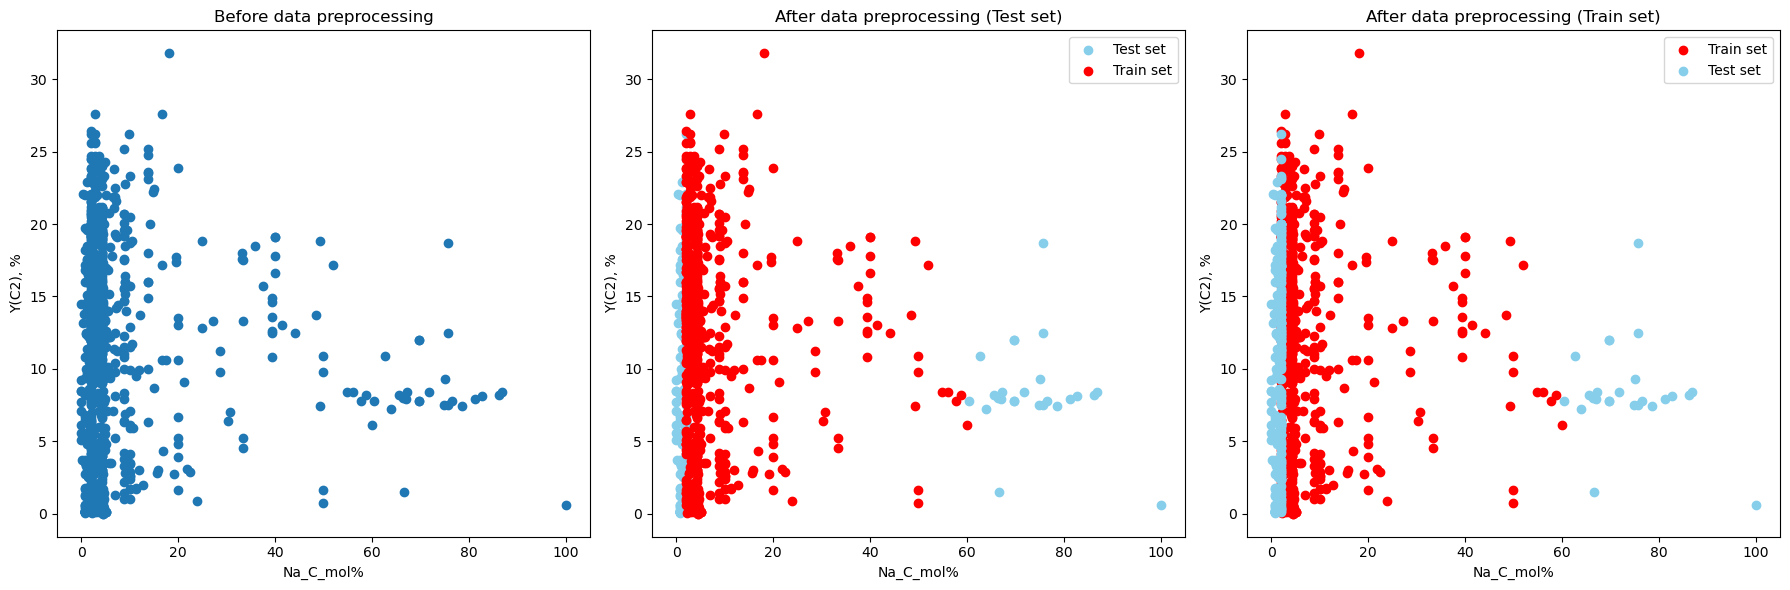

In [10]:
# Create a figure and a set of subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot before preprocessing
axs[0].scatter(filtered_Na['Na_C_mol%'], filtered_Na['Y(C2), %'])
axs[0].set_title('Before data preprocessing')
axs[0].set_xlabel('Na_C_mol%')
axs[0].set_ylabel('Y(C2), %')

# Plot after preprocessing with test set
axs[1].scatter(test_data['Na_C_mol%'], test_data['Y(C2), %'], color='skyblue', label='Test set')
axs[1].scatter(train_data['Na_C_mol%'], train_data['Y(C2), %'], color='red', label='Train set')
axs[1].set_title('After data preprocessing (Test set)')
axs[1].set_xlabel('Na_C_mol%')
axs[1].set_ylabel('Y(C2), %')
axs[1].legend()

# Plot after preprocessing with train set
axs[2].scatter(train_data['Na_C_mol%'], train_data['Y(C2), %'], color='red', label='Train set')
axs[2].scatter(test_data['Na_C_mol%'], test_data['Y(C2), %'], color='skyblue', label='Test set')
axs[2].set_title('After data preprocessing (Train set)')
axs[2].set_xlabel('Na_C_mol%')
axs[2].set_ylabel('Y(C2), %')
axs[2].legend()

# Show plots
plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the StandardScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both the training and test data
Na_train_scaled = scaler.fit_transform(filtered_Na[input_columns])
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_1 = MinMaxScaler()

# Reshape the output_column to be 2D
output_scaled = scaler_1.fit_transform(filtered_Na[output_column].values.reshape(-1, 1))

# Reshape the y_train and y_test to be 2D
y_train_scaled = scaler_1.transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_1.transform(y_test.values.reshape(-1, 1))

In [12]:
print("Mean:", np.mean(y_train_scaled))
print("Standard Deviation:", np.std(y_train_scaled))
print("Min:", np.min(y_train_scaled))
print("Max:", np.max(y_train_scaled))

print("Mean:", np.mean(y_test_scaled))
print("Standard Deviation:", np.std(y_test_scaled))
print("Min:", np.min(y_test_scaled))
print("Max:", np.max(y_test_scaled))


print(y_train.describe())
print(y_test.describe())

Mean: 0.39531004560240685
Standard Deviation: 0.22032307713545826
Min: 0.0
Max: 1.0
Mean: 0.3221357262466286
Standard Deviation: 0.21448534328840865
Min: 0.0008396305625524769
Max: 0.8238977097268213
count    700.000000
mean      12.571041
std        7.011218
min        0.000300
25%        7.000000
50%       13.600000
75%       18.025000
max       31.800000
Name: Y(C2), %, dtype: float64
count    293.000000
mean      10.244119
std        6.832239
min        0.027000
25%        3.700000
50%       10.400000
75%       16.500000
max       26.200000
Name: Y(C2), %, dtype: float64


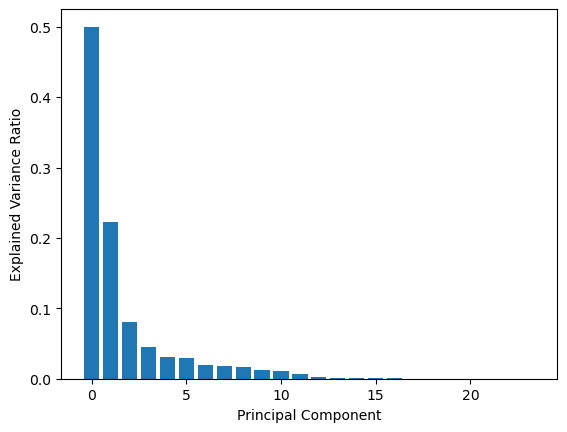

6


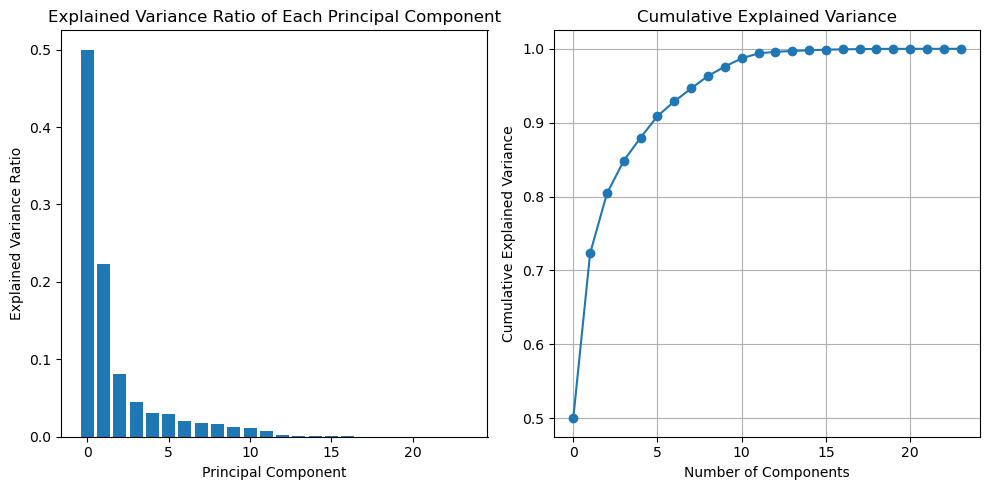

In [13]:
from sklearn.decomposition import PCA

# 데이터를 중앙에 맞춤 (선택 사항, PCA 내부적으로 수행됨)
# X_train_centered = X_train - np.mean(X_train, axis=0)
# X_test_centered = X_test - np.mean(X_test, axis=0)

# PCA 객체 생성
pca = PCA()

# PCA를 학습 데이터에 적합시킴
pca.fit(filtered_Na[input_columns])

# 설명된 분산의 비율을 확인
explained_var_ratio = pca.explained_variance_ratio_

# 설명된 분산의 비율을 시각화
plt.bar(range(len(explained_var_ratio)), explained_var_ratio)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

# 설명된 분산이 95% 이상이 되는 주성분 개수 선택
n_components = np.where(np.cumsum(explained_var_ratio) >= 0.90)[0][0] + 1

print(n_components)

# 선택된 주성분 개수로 PCA 다시 수행
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 설명된 분산의 누적 비율
cumulative_explained_var = np.cumsum(explained_var_ratio)

# 개별 주성분에 대한 설명된 분산 시각화
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(len(explained_var_ratio)), explained_var_ratio)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Each Principal Component')

# 누적 설명된 분산 시각화
plt.subplot(1, 2, 2)
plt.plot(range(len(cumulative_explained_var)), cumulative_explained_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error

# Initialize a dictionary to store the best parameters for each model
best_params = {}

# Linear Regression
def optimize_lr(fit_intercept):
    fit_intercept = bool(round(fit_intercept))
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    predictions = np.maximum(predictions, 0)  # Set lower bound to 0
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

optimizer_lr = BayesianOptimization(f=optimize_lr, pbounds={"fit_intercept": (0, 1)}, random_state=42, allow_duplicate_points=True)
optimizer_lr.maximize(init_points=40, n_iter=200)
best_params['Linear Regression'] = optimizer_lr.max['params']

# Decision Tree Regressor
def optimize_dtr(max_depth, min_samples_split):
    max_depth = int(round(max_depth))
    min_samples_split = int(round(min_samples_split))
    model = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    predictions = np.maximum(predictions, 0)  # Set lower bound to 0
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

optimizer_dtr = BayesianOptimization(f=optimize_dtr, pbounds={"max_depth": (1, 32), "min_samples_split": (2, 10)}, random_state=42, allow_duplicate_points=True)
optimizer_dtr.maximize(init_points=40, n_iter=200)
best_params['Decision Tree Regressor'] = optimizer_dtr.max['params']

# K-NN
def optimize_knn(n_neighbors, p):
    model = KNeighborsRegressor(n_neighbors=int(n_neighbors), p=p)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    predictions = np.maximum(predictions, 0)  # Set lower bound to 0
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

optimizer_knn = BayesianOptimization(f=optimize_knn, pbounds={"n_neighbors": (1, 20), "p": (1, 2)}, random_state=42, allow_duplicate_points=True)
optimizer_knn.maximize(init_points=40, n_iter=200)
best_params['K-NN'] = optimizer_knn.max['params']

# SVR
def optimize_svr(C, epsilon):
    model = SVR(C=C, epsilon=epsilon)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    predictions = np.maximum(predictions, 0)  # Set lower bound to 0
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

optimizer_svr = BayesianOptimization(f=optimize_svr, pbounds={"C": (1, 100), "epsilon": (0.01, 0.1)}, random_state=42, allow_duplicate_points=True)
optimizer_svr.maximize(init_points=40, n_iter=200)
best_params['SVR'] = optimizer_svr.max['params']

# GPR
def optimize_gpr(alpha):
    model = GaussianProcessRegressor(alpha=alpha)
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    predictions = np.maximum(predictions, 0)  # Set lower bound to 0
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

optimizer_gpr = BayesianOptimization(f=optimize_gpr, pbounds={"alpha": (0.01, 1)}, random_state=42, allow_duplicate_points=True)
optimizer_gpr.maximize(init_points=40, n_iter=200)
best_params['GaussianProcessRegressor'] = optimizer_gpr.max['params']

# RFR
def optimize_rfr(n_estimators, max_depth):
    model = RandomForestRegressor(n_estimators=int(n_estimators), max_depth=int(max_depth))
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    predictions = np.maximum(predictions, 0)  # Set lower bound to 0
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

optimizer_rfr = BayesianOptimization(f=optimize_rfr, pbounds={"n_estimators": (50, 200), "max_depth": (5, 50)}, random_state=42, allow_duplicate_points=True)
optimizer_rfr.maximize(init_points=40, n_iter=200)
best_params['RandomForestRegressor'] = optimizer_rfr.max['params']

# XGBoost
def optimize_xgb(learning_rate, n_estimators):
    model = XGBRegressor(learning_rate=learning_rate, n_estimators=int(n_estimators))
    model.fit(X_train_pca, y_train_scaled.ravel())
    predictions = model.predict(X_train_pca)
    predictions = np.maximum(predictions, 0)  # Set lower bound to 0
    return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

optimizer_xgb = BayesianOptimization(f=optimize_xgb, pbounds={"learning_rate": (0.01, 0.3), "n_estimators": (50, 200)}, random_state=42, allow_duplicate_points=True)
optimizer_xgb.maximize(init_points=40, n_iter=200)
best_params['XGBRegressor'] = optimizer_xgb.max['params']

|   iter    |  target   | fit_in... |
-------------------------------------
| 1         | -0.4232   | 0.3745    |
| 2         | -0.2037   | 0.9507    |
| 3         | -0.2037   | 0.732     |
| 4         | -0.2037   | 0.5987    |
| 5         | -0.4232   | 0.156     |
| 6         | -0.4232   | 0.156     |
| 7         | -0.4232   | 0.05808   |
| 8         | -0.2037   | 0.8662    |
| 9         | -0.2037   | 0.6011    |
| 10        | -0.2037   | 0.7081    |
| 11        | -0.4232   | 0.02058   |
| 12        | -0.2037   | 0.9699    |
| 13        | -0.2037   | 0.8324    |
| 14        | -0.4232   | 0.2123    |
| 15        | -0.4232   | 0.1818    |
| 16        | -0.4232   | 0.1834    |
| 17        | -0.4232   | 0.3042    |
| 18        | -0.2037   | 0.5248    |
| 19        | -0.4232   | 0.4319    |
| 20        | -0.4232   | 0.2912    |
| 21        | -0.2037   | 0.6119    |
| 22        | -0.4232   | 0.1395    |
| 23        | -0.4232   | 0.2921    |
| 24        | -0.4232   | 0.3664    |
| 25        

In [ ]:
# # MLP
# def optimize_mlp(learning_rate, hidden_units_1, hidden_units_2):
#     model = Sequential()
#     model.add(Dense(int(hidden_units_1), activation='relu', input_shape=(X_train_pca.shape[1],)))
#     model.add(Dense(int(hidden_units_2), activation='relu'))
#     model.add(Dense(1, activation='relu'))
    
#     optimizer = Adam(learning_rate=learning_rate)
    
#     model.compile(loss='mean_squared_error', optimizer=optimizer)
    
#     model.fit(X_train_pca, y_train_scaled, epochs=100, batch_size=16, verbose=0)
    
#     predictions = model.predict(X_train_pca).flatten()
    
#     return -np.sqrt(mean_squared_error(y_train_scaled, predictions))

# # Bayesian Optimization
# pbounds = {'learning_rate': (0.0001, 0.01), 'hidden_units_1': (10, 100), 'hidden_units_2': (10, 100)}

# optimizer_mlp = BayesianOptimization(
#     f=optimize_mlp,
#     pbounds=pbounds,
#     random_state=42,
# )

# optimizer_mlp.maximize(init_points=40, n_iter=200)
# best_params['MLPRegressor'] = optimizer_mlp.max['params']

|   iter    |  target   | hidden... | hidden... | learni... |
-------------------------------------------------------------
22/22 [==============================] - 0s 414us/step
| 1         | -0.1395   | 43.71     | 95.56     | 0.007347  |
22/22 [==============================] - 0s 444us/step
| 2         | -0.15     | 63.88     | 24.04     | 0.001644  |
22/22 [==============================] - 0s 438us/step
| 3         | -0.1535   | 15.23     | 87.96     | 0.006051  |
22/22 [==============================] - 0s 371us/step
| 4         | -0.1578   | 73.73     | 11.85     | 0.009702  |
22/22 [==============================] - 0s 415us/step
| 5         | -0.1474   | 84.92     | 29.11     | 0.0019    |
22/22 [==============================] - 0s 402us/step
| 6         | -0.1455   | 26.51     | 37.38     | 0.005295  |
22/22 [==============================] - 0s 394us/step
| 7         | -0.1476   | 48.88     | 36.21     | 0.006157  |
22/22 [==============================] - 0s 417us/step
| 

In [ ]:
print(best_params)

{'Linear Regression': {'fit_intercept': 0.9507143064099162}, 'Decision Tree Regressor': {'max_depth': 30.762024725077676, 'min_samples_split': 2.0}, 'K-NN': {'n_neighbors': 1.3911053916202465, 'p': 1.9699098521619942}, 'SVR': {'C': 98.64365056667714, 'epsilon': 0.06884624055708345}, 'GaussianProcessRegressor': {'alpha': 0.01000000000000012}, 'RandomForestRegressor': {'max_depth': 44.054690575715604, 'n_estimators': 178.9198499272925}, 'XGBRegressor': {'learning_rate': 0.29020520175502307, 'n_estimators': 191.2643901381674}, 'MLPRegressor': {'hidden_units_1': 99.2664272653227, 'hidden_units_2': 87.2746977461748, 'learning_rate': 0.0017297315399573314}}


In [ ]:
from sklearn.metrics import r2_score
# Initialize a dictionary to store the validation MSE for each model
validation_mse = {}

# Linear Regression
best_lr_params = best_params['Linear Regression']
best_lr_params['fit_intercept'] = bool(round(best_lr_params['fit_intercept']))
lr_model = LinearRegression(**best_lr_params)
lr_model.fit(X_train_pca, y_train_scaled)
lr_predictions = lr_model.predict(X_test_pca)
lr_predictions = np.maximum(lr_predictions, 0)  # Set lower bound to 0
lr_predictions_train = lr_model.predict(X_train_pca)
lr_predictions_train = np.maximum(lr_predictions_train, 0)  # Set lower bound to 0
lr_rmse = np.sqrt(mean_squared_error(y_test_scaled, lr_predictions))
validation_mse['Linear Regression'] = lr_rmse
lr_r2 = r2_score(y_train_scaled, lr_predictions_train)
lr_r2_test = r2_score(y_test_scaled, lr_predictions)
lr_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, lr_predictions_train))

# K-NN
best_knn_params = best_params['K-NN']
best_knn_params['n_neighbors'] = int(round(best_knn_params['n_neighbors']))
knn_model = KNeighborsRegressor(**best_knn_params)
knn_model.fit(X_train_pca, y_train_scaled)
knn_predictions = knn_model.predict(X_test_pca)
knn_predictions = np.maximum(knn_predictions, 0)  # Set lower bound to 0
knn_predictions_train = knn_model.predict(X_train_pca)
knn_predictions_train = np.maximum(knn_predictions_train, 0)  # Set lower bound to 0
knn_rmse = np.sqrt(mean_squared_error(y_test_scaled, knn_predictions))
validation_mse['K-NN'] = knn_rmse
knn_r2 = r2_score(y_train_scaled, knn_predictions_train)
knn_r2_test = r2_score(y_test_scaled, knn_predictions)
knn_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, knn_predictions_train))

# SVR
best_svr_params = best_params['SVR']
svr_model = SVR(**best_svr_params)
svr_model.fit(X_train_pca, y_train_scaled)
svr_predictions = svr_model.predict(X_test_pca)
svr_predictions = np.maximum(svr_predictions, 0)  # Set lower bound to 0
svr_predictions_train = svr_model.predict(X_train_pca)
svr_predictions_train = np.maximum(svr_predictions_train, 0)  # Set lower bound to 0
svr_rmse = np.sqrt(mean_squared_error(y_test_scaled, svr_predictions))
validation_mse['SVR'] = svr_rmse
svr_r2 = r2_score(y_train_scaled, svr_predictions_train)
svr_r2_test = r2_score(y_test_scaled, svr_predictions)
svr_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, svr_predictions_train))

# GPR
best_gpr_params = best_params['GaussianProcessRegressor']
gpr_model = GaussianProcessRegressor(**best_gpr_params)
gpr_model.fit(X_train_pca, y_train_scaled)
gpr_predictions = gpr_model.predict(X_test_pca)
gpr_predictions = np.maximum(gpr_predictions, 0)  # Set lower bound to 0
gpr_predictions_train = gpr_model.predict(X_train_pca)
gpr_predictions_train = np.maximum(gpr_predictions_train, 0)  # Set lower bound to 0
gpr_rmse = np.sqrt(mean_squared_error(y_test_scaled, gpr_predictions))
validation_mse['GaussianProcessRegressor'] = gpr_rmse
gpr_r2 = r2_score(y_train_scaled, gpr_predictions_train)
gpr_r2_test = r2_score(y_test_scaled, gpr_predictions)
gpr_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, gpr_predictions_train))

# RFR
best_rfr_params = best_params['RandomForestRegressor']
best_rfr_params['max_depth'] = int(round(best_rfr_params['max_depth']))
best_rfr_params['n_estimators'] = int(round(best_rfr_params['n_estimators']))
rfr_model = RandomForestRegressor(**best_rfr_params)
rfr_model.fit(X_train_pca, y_train_scaled)
rfr_predictions = rfr_model.predict(X_test_pca)
rfr_predictions = np.maximum(rfr_predictions, 0)  # Set lower bound to 0
rfr_predictions_train = rfr_model.predict(X_train_pca)
rfr_predictions_train = np.maximum(rfr_predictions_train, 0)  # Set lower bound to 0
rfr_rmse = np.sqrt(mean_squared_error(y_test_scaled, rfr_predictions))
validation_mse['RandomForestRegressor'] = rfr_rmse
rfr_r2 = r2_score(y_train_scaled, rfr_predictions_train)
rfr_r2_test = r2_score(y_test_scaled, rfr_predictions)
rfr_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, rfr_predictions_train))

# XGBoost
best_xgb_params = best_params['XGBRegressor']
best_xgb_params['n_estimators'] = int(round(best_xgb_params['n_estimators']))
xgb_model = XGBRegressor(**best_xgb_params)
xgb_model.fit(X_train_pca, y_train_scaled)
xgb_predictions = xgb_model.predict(X_test_pca)
xgb_predictions = np.maximum(xgb_predictions, 0)  # Set lower bound to 0
xgb_predictions_train = xgb_model.predict(X_train_pca)
xgb_predictions_train = np.maximum(xgb_predictions_train, 0)  # Set lower bound to 0
xgb_rmse = np.sqrt(mean_squared_error(y_test_scaled, xgb_predictions))
validation_mse['XGBRegressor'] = xgb_rmse
xgb_r2 = r2_score(y_train_scaled, xgb_predictions_train)
xgb_r2_test = r2_score(y_test_scaled, xgb_predictions)
xgb_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, xgb_predictions_train))

# # MLP
# # Keras 모델로 MLP 구현
# best_mlp_params = best_params['MLPRegressor']
# best_mlp_params['hidden_units_1'] = int(round(best_mlp_params['hidden_units_1']))
# best_mlp_params['hidden_units_2'] = int(round(best_mlp_params['hidden_units_2']))

# # 최적의 파라미터로 모델 생성
# mlp_model = Sequential()
# mlp_model.add(Dense(best_mlp_params['hidden_units_1'], activation='relu', input_shape=(X_train_pca.shape[1],)))
# mlp_model.add(Dense(best_mlp_params['hidden_units_2'], activation='relu'))
# mlp_model.add(Dense(1, activation='relu'))

# optimizer = Adam(learning_rate=best_mlp_params['learning_rate'])

# mlp_model.compile(loss='mean_squared_error', optimizer=optimizer)

# # 모델 학습
# mlp_model.fit(X_train_pca, y_train_scaled, epochs=50, batch_size=32)

# # 예측
# mlp_predictions = mlp_model.predict(X_test_pca).flatten()
# mlp_predictions_train = mlp_model.predict(X_train_pca).flatten()

# # 평가
# mlp_rmse = np.sqrt(mean_squared_error(y_test_scaled, mlp_predictions))
# mlp_r2 = r2_score(y_train_scaled, mlp_predictions_train)
# mlp_r2_test = r2_score(y_test_scaled, mlp_predictions)
# mlp_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, mlp_predictions_train))

# Initialize dictionary to hold predictions from each model for Bayesian Model Averaging
predictions_dict = {}

# Get predictions from each trained model and store in the dictionary
predictions_dict['Linear Regression'] = lr_model.predict(X_test_pca)
predictions_dict['K-NN'] = knn_model.predict(X_test_pca)
predictions_dict['SVR'] = svr_model.predict(X_test_pca)
predictions_dict['GaussianProcessRegressor'] = gpr_model.predict(X_test_pca)
predictions_dict['RandomForestRegressor'] = rfr_model.predict(X_test_pca)
predictions_dict['XGBRegressor'] = xgb_model.predict(X_test_pca)
# predictions_dict['MLPRegressor'] = mlp_model.predict(X_test_pca)

c:\Users\OJH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\OJH\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Epoch 1/50
22/22 [==============================] - 0s 570us/step - loss: 0.0852
Epoch 2/50
22/22 [==============================] - 0s 522us/step - loss: 0.0429
Epoch 3/50
22/22 [==============================] - 0s 522us/step - loss: 0.0406
Epoch 4/50
22/22 [==============================] - 0s 522us/step - loss: 0.0382
Epoch 5/50
22/22 [==============================] - 0s 475us/step - loss: 0.0371
Epoch 6/50
22/22 [==============================] - 0s 475us/step - loss: 0.0363
Epoch 7/50
22/22 [==============================] - 0s 475us/step - loss: 0.0363
Epoch 8/50
22/22 [==============================] - 0s 475us/step - loss: 0.0354
Epoch 9/50
22/22 [==============================] - 0s 475us/step - loss: 0.0344
Epoch 10/50
22/22 [==============================] - 0s 475us/step - loss: 0.0337
Epoch 11/50
22/22 [==============================] - 0s 443us/step - loss: 0.0332
Epoch 12/50
22/22 [==============================] - 0s 427us/step - loss: 0.0338
Epoch 13/50
22/22 [======

[0.20376457389265762, 0.3093423777370253, 0.20596183815047897, 0.18601141499321827, 0.18297253298776064, 0.20055607111669935, 0.1834230153294286]
[0.09746901505058292, -1.0800970502065144, 0.07789945729888659, 0.2478855159781086, 0.2722594746381781, 0.12566797535312924, 0.26867163751144174]
[0.1453722862818475, 0.9781839006677799, 0.5407440219531442, 0.38696018891592276, 0.935367215666861, 0.9883986165434341, 0.49346087311240827]


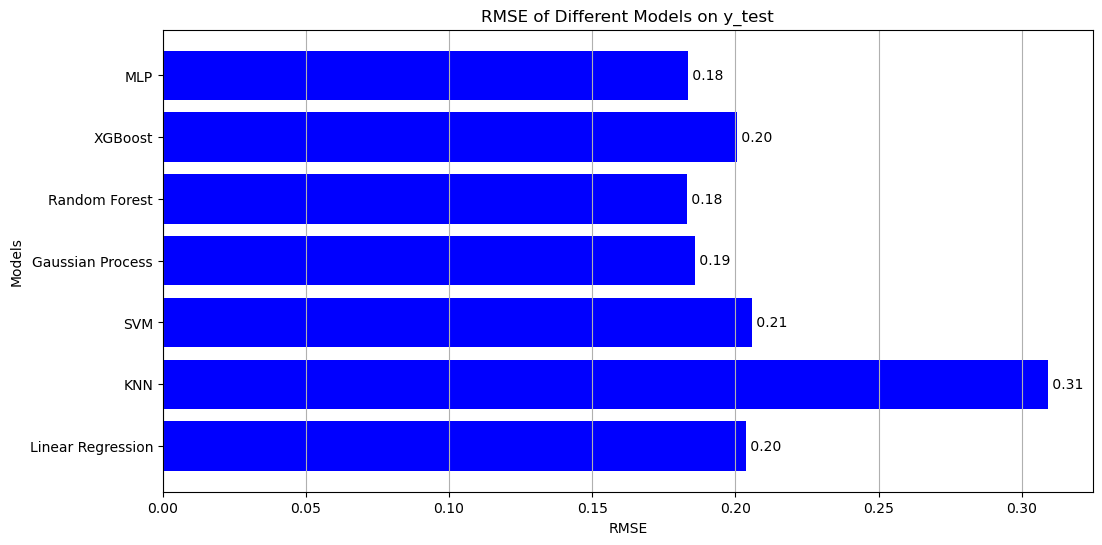

In [ ]:
print([lr_rmse, knn_rmse, svr_rmse, gpr_rmse, rfr_rmse, xgb_rmse])
print([lr_r2_test, knn_r2_test, svr_r2_test, gpr_r2_test, rfr_r2_test, xgb_r2_test])
print([lr_r2, knn_r2, svr_r2, gpr_r2, rfr_r2, xgb_r2])

mse_values = [lr_rmse, knn_rmse, svr_rmse, gpr_rmse, rfr_rmse, xgb_rmse]
r2_test_values = [lr_r2_test, knn_r2_test, svr_r2_test, gpr_r2_test, rfr_r2_test, xgb_r2_test]
r2_values = [lr_r2, knn_r2, svr_r2, gpr_r2, rfr_r2, xgb_r2]
model_names = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost']


# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names, mse_values, color='blue')
plt.xlabel('RMSE')
plt.ylabel('Models')
plt.title('RMSE of Different Models on y_test')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(mse_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

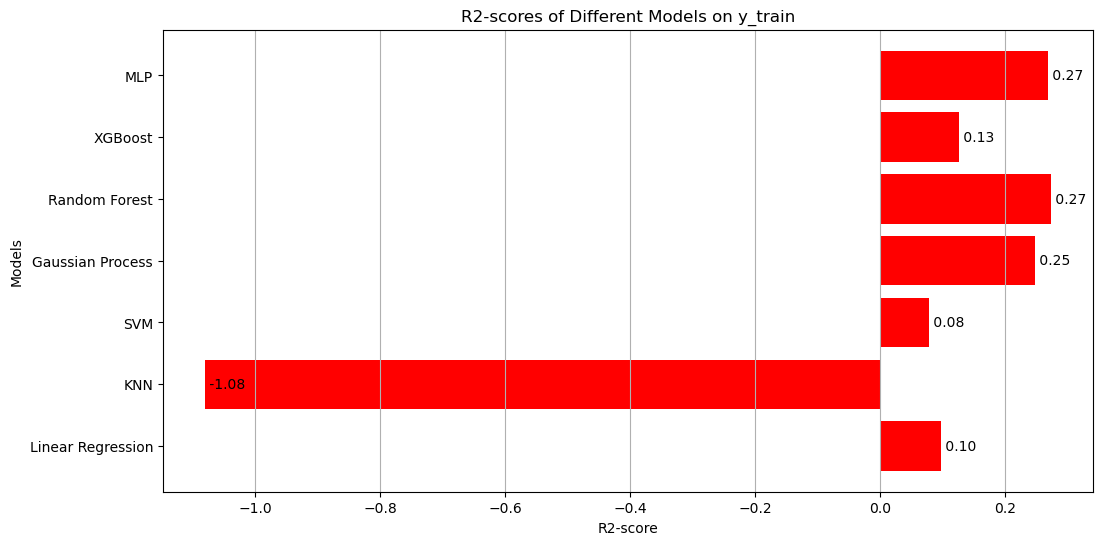

In [ ]:
# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names, r2_test_values, color='red')
plt.xlabel('R2-score')
plt.ylabel('Models')
plt.title('R2-scores of Different Models on y_train')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(r2_test_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

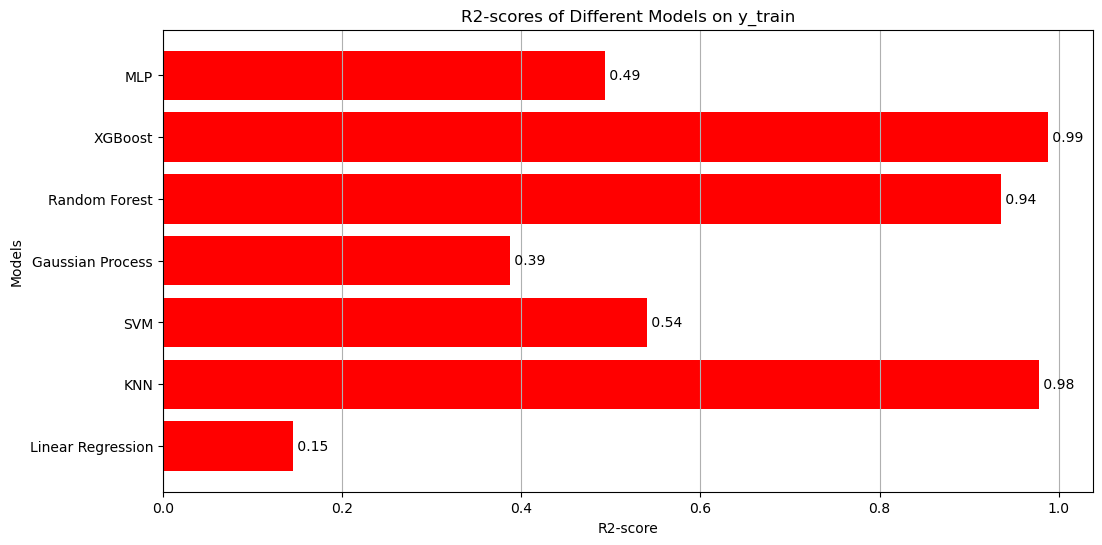

In [ ]:
# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names, r2_values, color='red')
plt.xlabel('R2-score')
plt.ylabel('Models')
plt.title('R2-scores of Different Models on y_train')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(r2_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

In [ ]:
# # 특성 중요도 가져오기
# feature_importances = rfr_model.feature_importances_

# # 특성 중요도를 데이터프레임으로 변환
# importance_df = pd.DataFrame({
#     'Feature': input_columns,
#     'Importance': feature_importances
# })

# # 특성 중요도를 내림차순으로 정렬
# importance_df = importance_df.sort_values(by='Importance', ascending=False)

# # 특성 중요도 시각화
# plt.figure(figsize=(10, 8))
# plt.barh(importance_df['Feature'], importance_df['Importance'], align='center')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.title('Feature Importance')
# plt.show()

In [ ]:
# # 특성 중요도 가져오기
# feature_importances = xgb_model.feature_importances_

# # 특성 중요도를 데이터프레임으로 변환
# importance_df = pd.DataFrame({
#     'Feature': input_columns,
#     'Importance': feature_importances
# })

# # 특성 중요도를 내림차순으로 정렬
# importance_df = importance_df.sort_values(by='Importance', ascending=False)

# # 특성 중요도 시각화
# plt.figure(figsize=(10, 8))
# plt.barh(importance_df['Feature'], importance_df['Importance'], align='center')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.title('Feature Importance')
# plt.show()

In [ ]:
print(best_params)

{'Linear Regression': {'fit_intercept': True}, 'Decision Tree Regressor': {'max_depth': 30.762024725077676, 'min_samples_split': 2.0}, 'K-NN': {'n_neighbors': 1, 'p': 1.9699098521619942}, 'SVR': {'C': 98.64365056667714, 'epsilon': 0.06884624055708345}, 'GaussianProcessRegressor': {'alpha': 0.01000000000000012}, 'RandomForestRegressor': {'max_depth': 44, 'n_estimators': 179}, 'XGBRegressor': {'learning_rate': 0.29020520175502307, 'n_estimators': 191}, 'MLPRegressor': {'hidden_units_1': 99, 'hidden_units_2': 87, 'learning_rate': 0.0017297315399573314}}


In [ ]:
from sklearn.ensemble import VotingRegressor
# from scikeras.wrappers import KerasRegressor

# Initialize the first-level base models with the optimized hyperparameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
# Define a function to create the MLP model
# def create_mlp_model():
#     model = Sequential()
#     model.add(Dense(best_mlp_params['hidden_units_1'], activation='relu', input_shape=(X_train_pca.shape[1],)))
#     model.add(Dense(best_mlp_params['hidden_units_2'], activation='relu'))
#     model.add(Dense(1, activation='relu'))
#     model.compile(loss='mean_squared_error', optimizer='adam')
#     return model

# # Create a KerasRegressor object from the MLP model function
# mlp_model = KerasRegressor(model=create_mlp_model, epochs=100, batch_size=32, verbose=0)

# Create a VotingRegressor instance
voting_reg = VotingRegressor(estimators=[
    ('lr', lr_model), 
    ('knn', knn_model), 
    ('svr', svr_model),
    ('gpr', gpr_model), 
    ('rfr', rfr_model), 
    ('xgb', xgb_model),
    # ('mlp', mlp_model)
])

# Fit the ensemble model
voting_reg.fit(X_train_pca, y_train_scaled)

# Make predictions on validation set
voting_predictions = voting_reg.predict(X_test_pca)
voting_predictions = np.maximum(voting_predictions, 0)  # Set lower bound to 0
voting_predictions_train = voting_reg.predict(X_train_pca)
voting_predictions_train = np.maximum(voting_predictions_train, 0)

# Calculate the MSE
voting_rmse = np.sqrt(mean_squared_error(y_test_scaled.ravel(), voting_predictions))
voting_train_rmse = np.sqrt(mean_squared_error(y_train_scaled.ravel(), voting_predictions_train))
voting_test_r2 = r2_score(y_test_scaled.ravel(), voting_predictions)
voting_r2 = r2_score(y_train_scaled, voting_reg.predict(X_train_pca))

# Add to the validation MSE dictionary
validation_mse['VotingRegressor'] = voting_rmse

print(f"Voting Regressor RMSE: {voting_rmse}")

c:\Users\OJH\anaconda3\Lib\site-packages\sklearn\ensemble\_voting.py:604: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Voting Regressor RMSE: 0.17402871246991236


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Initialize the first-level base models with the optimized hyperparameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
# Define a function to create the MLP model
# def create_mlp_model():
#     model = Sequential()
#     model.add(Dense(best_mlp_params['hidden_units_1'], activation='relu', input_shape=(X_train_pca.shape[1],)))
#     model.add(Dense(best_mlp_params['hidden_units_2'], activation='relu'))
#     model.add(Dense(1, activation='relu'))
#     model.compile(loss='mean_squared_error', optimizer='adam')
#     return model

# # Create a KerasRegressor object from the MLP model function
# mlp_model = KerasRegressor(model=create_mlp_model, epochs=100, batch_size=32, verbose=0)

# Initialize the Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=[
        ('lr', lr_model),
        ('knn', knn_model),
        ('svr', svr_model),
        ('gpr', gpr_model),
        ('rfr', rfr_model),
        ('xgb', xgb_model),
        # ('mlp', mlp_model)
    ],
    final_estimator=LinearRegression()
)

# Fit the ensemble model
stacking_regressor.fit(X_train_pca, y_train_scaled)

# Make predictions on the validation set
stacking_predictions = stacking_regressor.predict(X_test_pca)
stacking_predictions = np.maximum(stacking_predictions, 0)  # Set lower bound to 0
stacking_predictions_train = stacking_regressor.predict(X_train_pca)
stacking_predictions_train = np.maximum(stacking_predictions_train, 0)  # Set lower bound to 0

# Calculate the MSE
stacking_rmse = np.sqrt(mean_squared_error(y_test_scaled, stacking_predictions))
stacking_rmse_train = np.sqrt(mean_squared_error(y_train_scaled, stacking_predictions_train))
stacking_r2 = r2_score(y_train_scaled, stacking_regressor.predict(X_train_pca))
stacking_r2_test = r2_score(y_test_scaled, stacking_predictions)

print(f"Stacking Regressor RMSE: {stacking_rmse}")

c:\Users\OJH\anaconda3\Lib\site-packages\sklearn\ensemble\_stacking.py:955: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Stacking Regressor RMSE: 0.1908192117425835


In [ ]:
# Evaluation function
def evaluate_model_with_added_test_samples(model, X_train, y_train, X_test, y_test):
    # Initial performance on the test set
    model.fit(X_train, y_train)
    initial_predictions = model.predict(X_test)
    initial_rmse = mean_squared_error(y_test, initial_predictions, squared=False)
    initial_r2 = r2_score(y_test, initial_predictions)
    
    # Record the metrics after adding test samples one-by-one
    updated_rmse_list = []
    updated_r2_list = []
    
    for i in range(len(X_test)):
        # Add one test sample to the training data
        X_train_expanded = pd.concat([X_train, X_test.iloc[[i]]])
        y_train_expanded = pd.concat([y_train, y_test.iloc[[i]]])
        
        # Re-train the model and get new predictions for the test set
        model.fit(X_train_expanded, y_train_expanded)
        updated_predictions = model.predict(X_test)
        
        # Calculate and record the updated metrics
        updated_rmse = mean_squared_error(y_test, updated_predictions, squared=False)
        updated_r2 = r2_score(y_test, updated_predictions)
        
        updated_rmse_list.append(updated_rmse)
        updated_r2_list.append(updated_r2)
        
    return (initial_rmse, initial_r2), (updated_rmse_list, updated_r2_list)

# Initialize dictionary to store results for all models
all_model_metrics = {}

# List of models with their best hyperparameters (replace with your own best_params)
best_params = {
    'Linear Regression': {},
    'Decision Tree Regressor': {},
    'K-NN': {},
    'SVR': {},
    'GaussianProcessRegressor': {},
    'RandomForestRegressor': {},
    'XGBRegressor': {}
}

# List of models
models = [
    {'name': 'Linear Regression', 'model': LinearRegression(**best_params['Linear Regression'])},
    {'name': 'Decision Tree Regressor', 'model': DecisionTreeRegressor(**best_params['Decision Tree Regressor'])},
    {'name': 'K-NN', 'model': KNeighborsRegressor(**best_params['K-NN'])},
    {'name': 'SVR', 'model': SVR(**best_params['SVR'])},
    {'name': 'GaussianProcessRegressor', 'model': GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])},
    {'name': 'RandomForestRegressor', 'model': RandomForestRegressor(**best_params['RandomForestRegressor'])},
    {'name': 'XGBRegressor', 'model': XGBRegressor(**best_params['XGBRegressor'])},
]

# Assume X_train, y_train, X_test, y_test are already defined

# Evaluate each model
for model_info in models:
    model_name = model_info['name']
    model = model_info['model']
    
    initial_metrics, updated_metrics = evaluate_model_with_added_test_samples(
        model, X_train, y_train, X_test, y_test)
    
    all_model_metrics[model_name] = {
        'Initial Metrics': initial_metrics,
        'Updated Metrics': updated_metrics
    }

# Now, all_model_metrics contains the initial and updated RMSE and R2 score for each model
    

[0.20376457389265762, 0.3093423777370253, 0.20596183815047897, 0.18601141499321827, 0.18297253298776064, 0.20055607111669935, 0.1834230153294286, 0.17402871246991236, 0.1908192117425835]


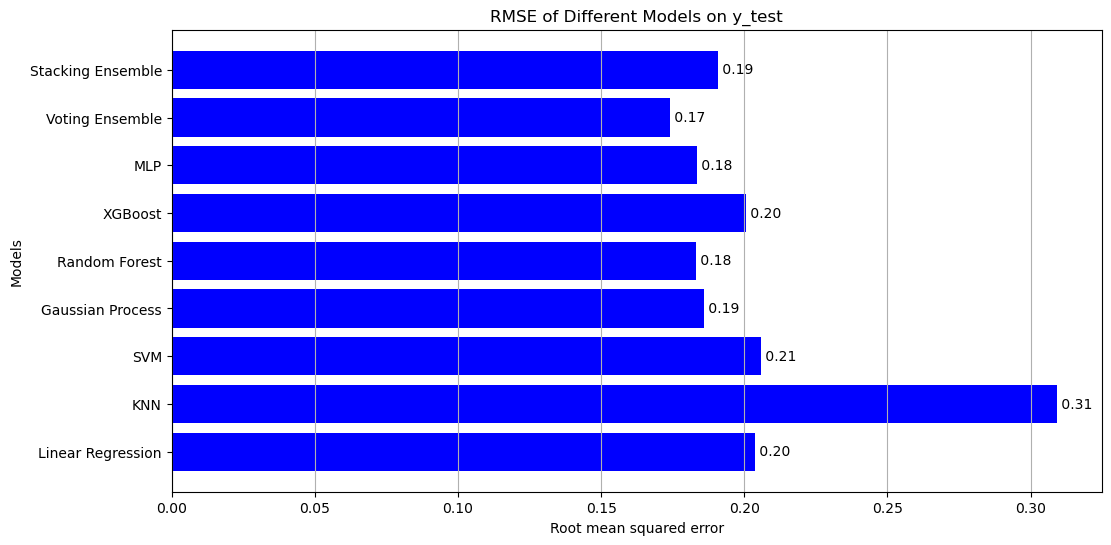

In [ ]:
print([lr_rmse, knn_rmse, svr_rmse, gpr_rmse, rfr_rmse, xgb_rmse, mlp_rmse, voting_rmse, stacking_rmse])

mse_values = [lr_rmse, knn_rmse, svr_rmse, gpr_rmse, rfr_rmse, xgb_rmse, mlp_rmse, voting_rmse, stacking_rmse]
model_names = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']


# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names, mse_values, color='blue')
plt.xlabel('Root mean squared error')
plt.ylabel('Models')
plt.title('RMSE of Different Models on y_test')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(mse_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

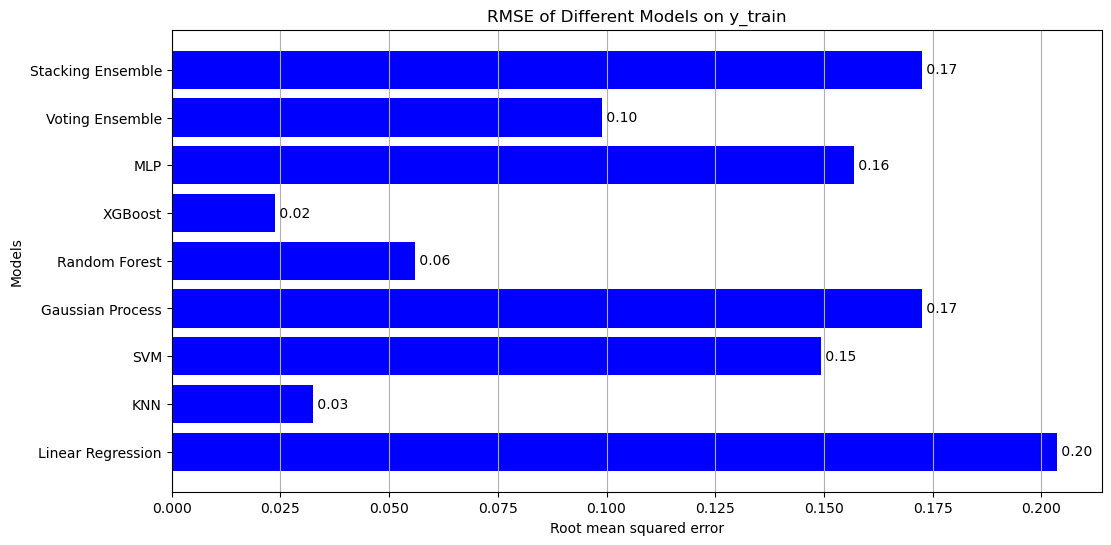

In [ ]:
rmse_train_values = [lr_rmse_train, knn_rmse_train, svr_rmse_train, gpr_rmse_train, rfr_rmse_train, xgb_rmse_train, mlp_rmse_train, voting_train_rmse, stacking_rmse_train]
model_names_train = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']

# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names_train, rmse_train_values, color='blue')
plt.xlabel('Root mean squared error')
plt.ylabel('Models')
plt.title('RMSE of Different Models on y_train')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(rmse_train_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

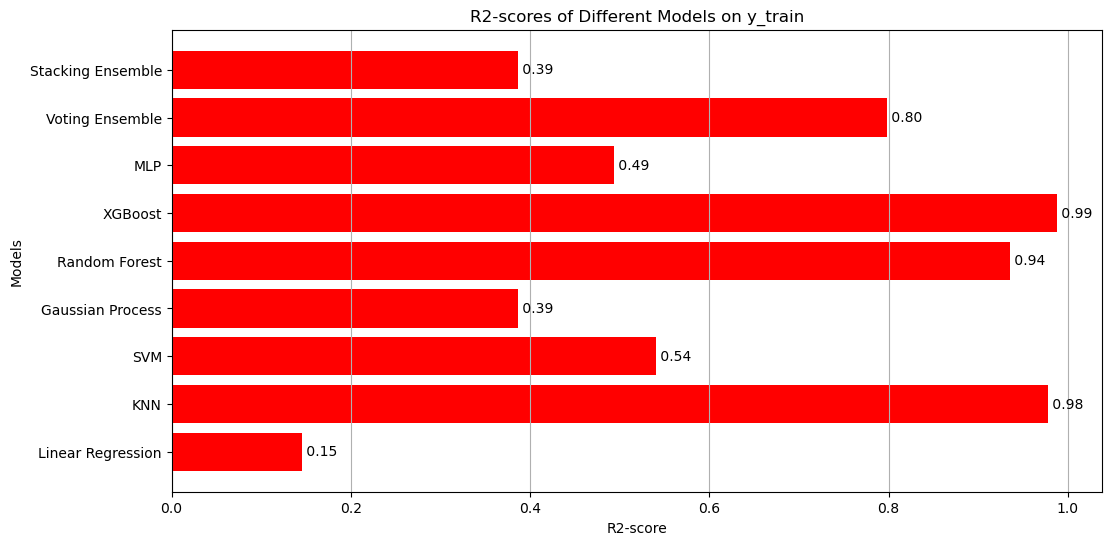

In [ ]:
r2_plus_values = [lr_r2, knn_r2, svr_r2, gpr_r2, rfr_r2, xgb_r2, mlp_r2, voting_r2, stacking_r2]
model_names_plus = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']

# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names_plus, r2_plus_values, color='red')
plt.xlabel('R2-score')
plt.ylabel('Models')
plt.title('R2-scores of Different Models on y_train')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(r2_plus_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

In [ ]:
lr_predictions_original = scaler_1.inverse_transform(lr_predictions.reshape(-1, 1))
knn_predictions_original = scaler_1.inverse_transform(knn_predictions.reshape(-1, 1))
svr_predictions_original = scaler_1.inverse_transform(svr_predictions.reshape(-1, 1))
gpr_predictions_original = scaler_1.inverse_transform(gpr_predictions.reshape(-1, 1))
rfr_predictions_original = scaler_1.inverse_transform(rfr_predictions.reshape(-1, 1))
xgb_predictions_original = scaler_1.inverse_transform(xgb_predictions.reshape(-1, 1))
mlp_predictions_original = scaler_1.inverse_transform(mlp_predictions.reshape(-1, 1))
voting_predictions_original = scaler_1.inverse_transform(voting_predictions.reshape(-1, 1))
stacking_predictions_original = scaler_1.inverse_transform(stacking_predictions.reshape(-1, 1))

results_df = pd.DataFrame({
    'y_test_original': y_test.ravel(),
    'lr_predictions_original': lr_predictions_original.ravel(),
    'knn_predictions_original': knn_predictions_original.ravel(),
    'svr_predictions_original': svr_predictions_original.ravel(),
    'gpr_predictions_original': gpr_predictions_original.ravel(),
    'rfr_predictions_original': rfr_predictions_original.ravel(),
    'xgb_predictions_original': xgb_predictions_original.ravel(),
    'mlp_predictions_original': mlp_predictions_original.ravel(),
    'voting_predictions_original': voting_predictions_original.ravel(),
    'stacking_predictions_original': stacking_predictions_original.ravel()
})

results_df.to_csv('model_predictions.csv', index=False)

results_df

,y_test_original,lr_predictions_original,knn_predictions_original,svr_predictions_original,gpr_predictions_original,rfr_predictions_original,xgb_predictions_original,mlp_predictions_original,voting_predictions_original,stacking_predictions_original
0,15.1,13.485760,0.7,7.210575,11.233542,12.313966,13.784392,8.882770,9.995201,14.456350
1,12.5,8.360691,13.3,12.313508,11.940326,12.193296,12.478591,10.847733,11.511072,12.465833
2,0.6,11.786549,0.7,0.000300,10.713673,12.708939,12.102342,6.940924,6.577029,12.164735
3,13.8,6.371169,19.2,12.611595,13.119466,4.805587,13.299534,14.862727,12.486536,10.635541
4,2.8,16.671841,15.6,13.310901,11.357317,13.589385,14.893752,12.126430,13.785896,12.861515
...,...,...,...,...,...,...,...,...,...,...
288,18.7,13.696847,18.7,17.355475,16.307074,19.064246,19.215643,17.930925,17.299281,15.034649
289,16.7,13.911821,16.7,18.660063,16.939107,16.655307,17.585608,16.886755,16.645695,14.675455
290,13.6,13.623285,13.6,15.212743,15.782745,13.556983,14.492163,16.130713,14.479602,13.651331
291,14.0,13.459110,14.0,12.948414,14.966046,13.448603,12.490384,14.991444,13.573530,12.905853


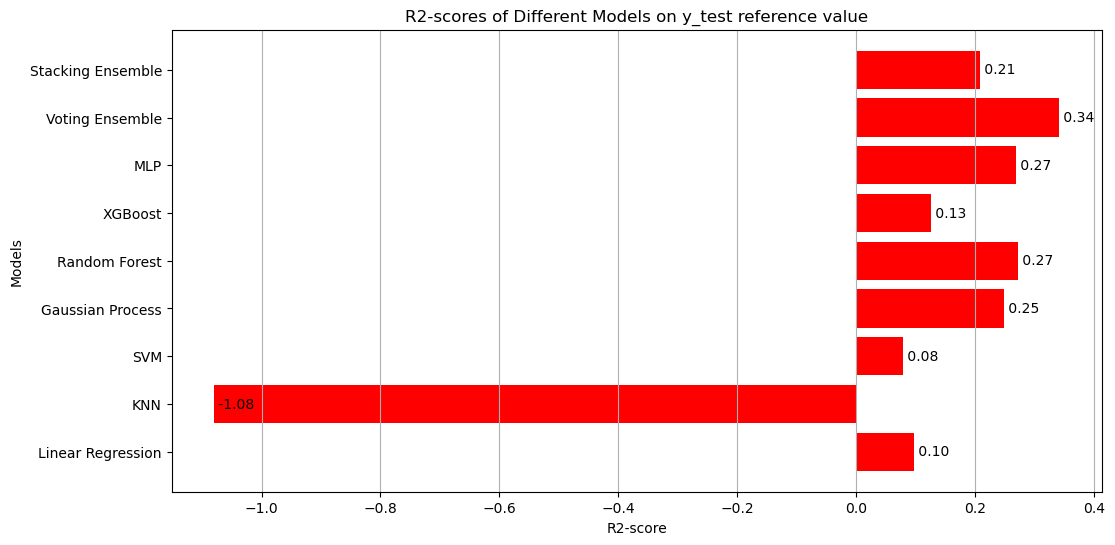

In [ ]:
lr_original_r2 = r2_score(y_test, lr_predictions_original)
knn_original_r2 = r2_score(y_test, knn_predictions_original)
svr_original_r2 = r2_score(y_test, svr_predictions_original)
gpr_original_r2 = r2_score(y_test, gpr_predictions_original)
rfr_original_r2 = r2_score(y_test, rfr_predictions_original)
xgb_original_r2 = r2_score(y_test, xgb_predictions_original)
mlp_original_r2 = r2_score(y_test, mlp_predictions_original)
voting_original_r2 = r2_score(y_test, voting_predictions_original)
stacking_original_r2 = r2_score(y_test, stacking_predictions_original)

r2_original_values = [lr_original_r2, knn_original_r2, svr_original_r2, gpr_original_r2, rfr_original_r2, xgb_original_r2, mlp_original_r2, voting_original_r2, stacking_original_r2]
model_names_9 = ['Linear Regression', 'KNN', 'SVM', 'Gaussian Process', 'Random Forest', 'XGBoost', 'MLP', 'Voting Ensemble', 'Stacking Ensemble']

# Plotting the MSE values for each model
plt.figure(figsize=(12, 6))
plt.barh(model_names_9, r2_original_values, color='red')
plt.xlabel('R2-score')
plt.ylabel('Models')
plt.title('R2-scores of Different Models on y_test reference value')
plt.grid(axis='x')

# Annotate each bar with the specific MSE value
for i, v in enumerate(r2_original_values):
    plt.text(v, i, " {:.2f}".format(v), va='center', color='black')

plt.show()

In [ ]:
# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original = lr_predictions_original.flatten()
xgb_predictions_original = xgb_predictions_original.flatten()

# Check the lengths
print(len(y_test), len(lr_predictions_original))

# Check the shapes if they are NumPy arrays
print(np.shape(y_test), np.shape(lr_predictions_original))

# If they are pandas Series, convert to NumPy arrays
if isinstance(y_test, pd.Series):
    y_test = y_test.values
if isinstance(lr_predictions_original, pd.Series):
    lr_predictions_original = lr_predictions_original.values

# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original = lr_predictions_original.flatten()

AttributeError: 'Series' object has no attribute 'flatten'

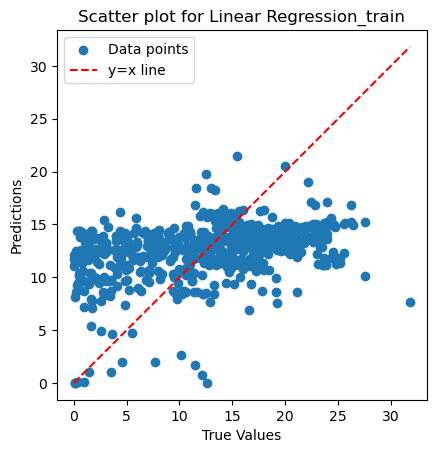

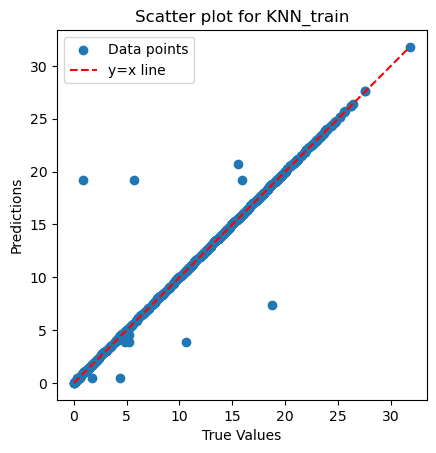

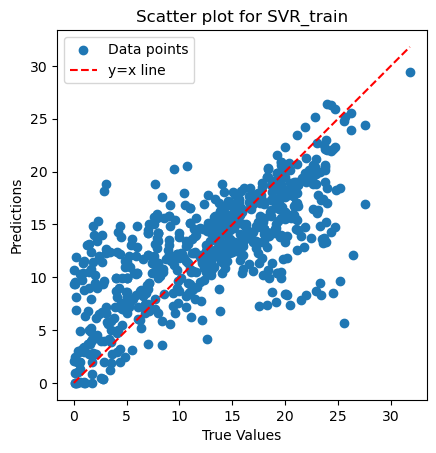

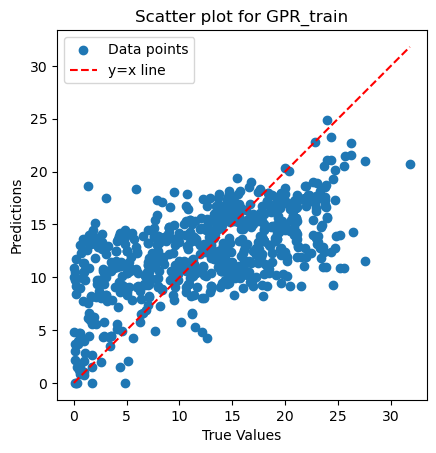

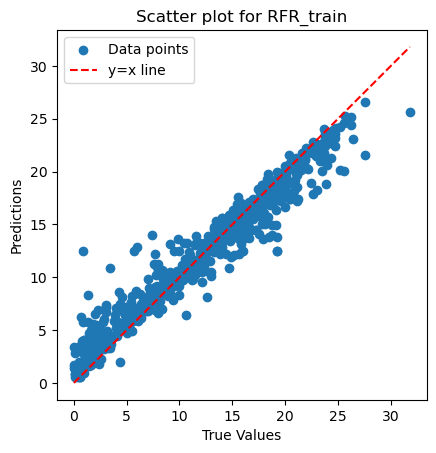

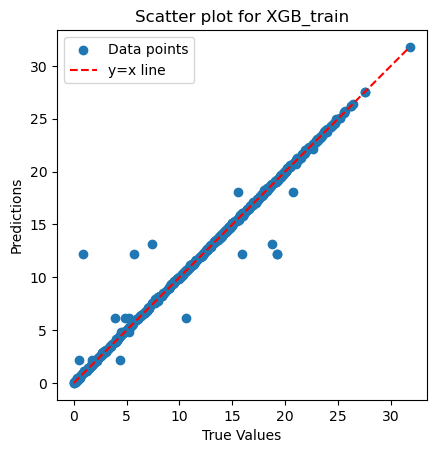

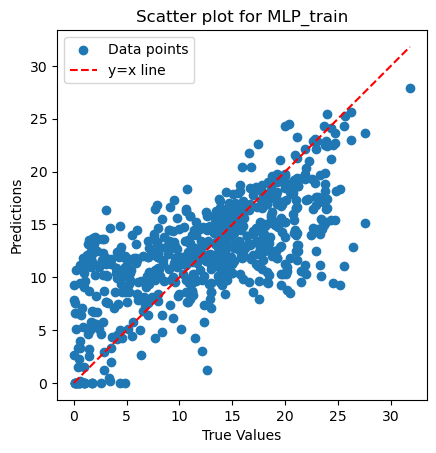

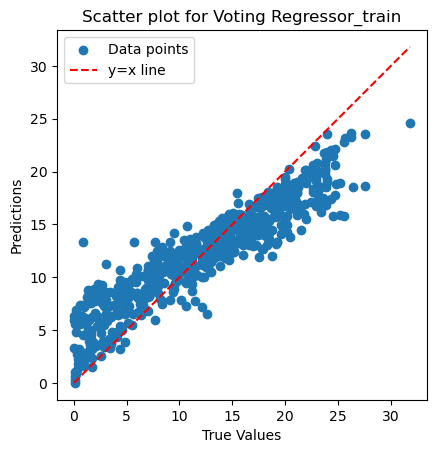

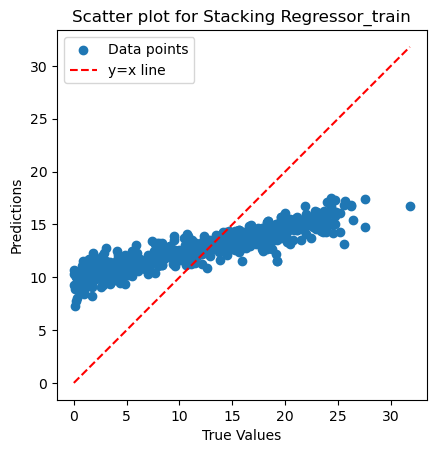

In [ ]:
lr_predictions_original_train = scaler_1.inverse_transform(lr_predictions_train.reshape(-1, 1))
knn_predictions_original_train = scaler_1.inverse_transform(knn_predictions_train.reshape(-1, 1))
svr_predictions_original_train = scaler_1.inverse_transform(svr_predictions_train.reshape(-1, 1))
gpr_predictions_original_train = scaler_1.inverse_transform(gpr_predictions_train.reshape(-1, 1))
rfr_predictions_original_train = scaler_1.inverse_transform(rfr_predictions_train.reshape(-1, 1))
xgb_predictions_original_train = scaler_1.inverse_transform(xgb_predictions_train.reshape(-1, 1))
mlp_predictions_original_train = scaler_1.inverse_transform(mlp_predictions_train.reshape(-1, 1))
voting_predictions_original_train = scaler_1.inverse_transform(voting_predictions_train.reshape(-1, 1))
stacking_predictions_original_train = scaler_1.inverse_transform(stacking_predictions_train.reshape(-1, 1))

# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original_train = lr_predictions_original_train.flatten()
svr_predictions_original_train = svr_predictions_original_train.flatten()
gpr_predictions_original_train = gpr_predictions_original_train.flatten()
rfr_predictions_original_train = rfr_predictions_original_train.flatten()
xgb_predictions_original_train = xgb_predictions_original_train.flatten()
mlp_predictions_original_train = mlp_predictions_original_train.flatten()
voting_predictions_original_train = voting_predictions_original_train.flatten()
stacking_predictions_original_train = stacking_predictions_original_train.flatten()

def plot_scatter(y_true, y_pred, model_name):
    plt.scatter(y_true, y_pred, label='Data points')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    
    # y=x 라인 추가
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x line')
    
    plt.axis('equal')
    plt.axis('square')
    plt.title(f'Scatter plot for {model_name}_train')
    plt.legend()
    plt.show()

# 각 모델에 대한 산점도 그리기
plot_scatter(y_train, lr_predictions_original_train, 'Linear Regression')
plot_scatter(y_train, knn_predictions_original_train, 'KNN')
plot_scatter(y_train, svr_predictions_original_train, 'SVR')
plot_scatter(y_train, gpr_predictions_original_train, 'GPR')
plot_scatter(y_train, rfr_predictions_original_train, 'RFR')
plot_scatter(y_train, xgb_predictions_original_train, 'XGB')
plot_scatter(y_train, mlp_predictions_original_train, 'MLP')
plot_scatter(y_train, voting_predictions_original_train, 'Voting Regressor')
plot_scatter(y_train, stacking_predictions_original_train, 'Stacking Regressor')

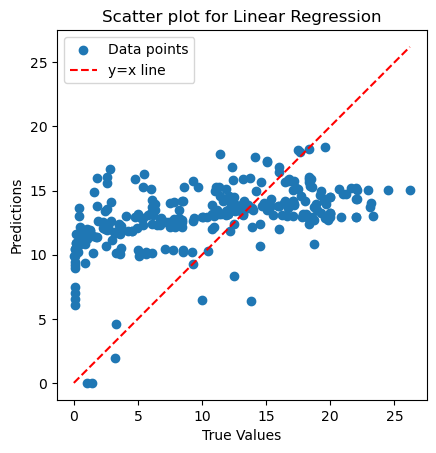

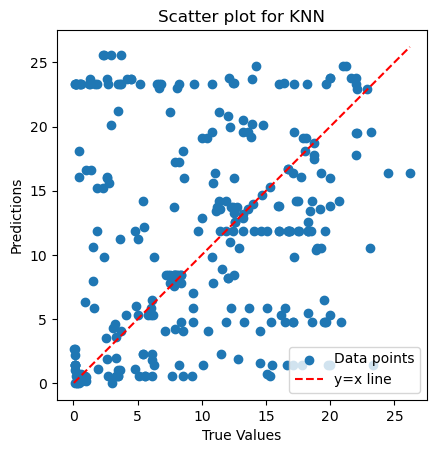

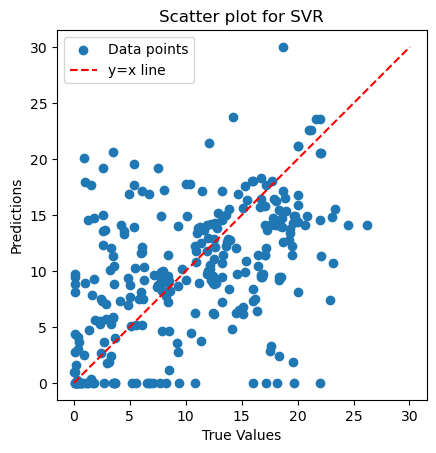

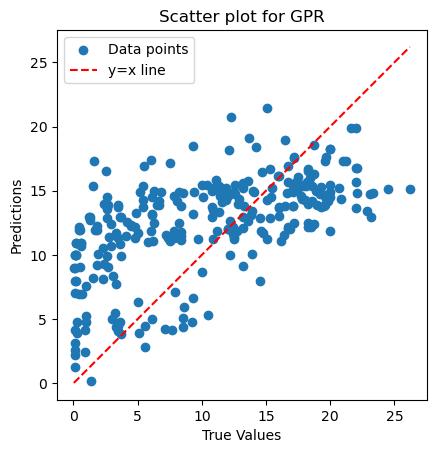

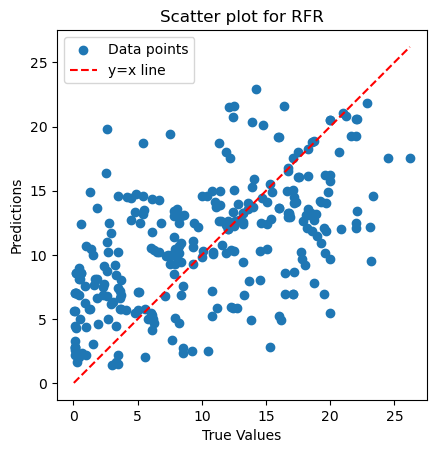

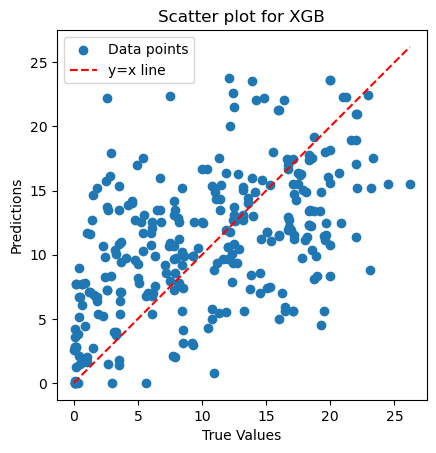

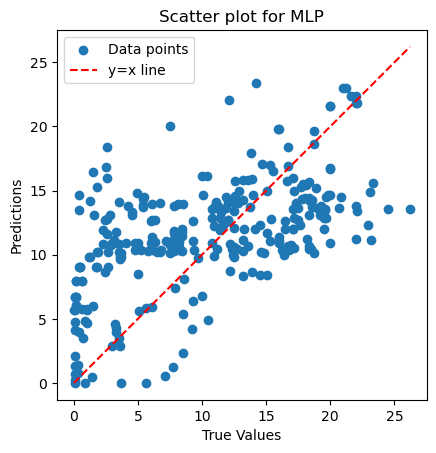

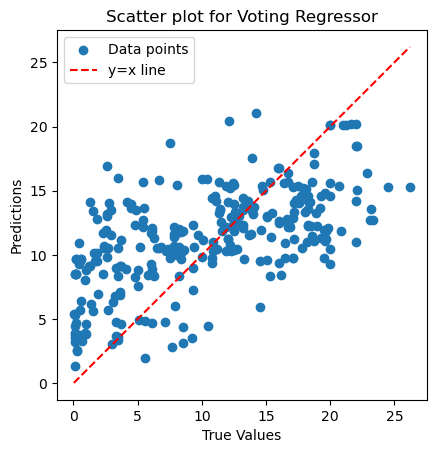

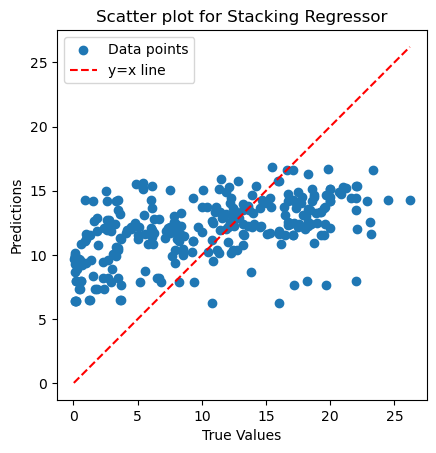

In [ ]:
def plot_scatter(y_true, y_pred, model_name):
    plt.scatter(y_true, y_pred, label='Data points')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    
    # y=x 라인 추가
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x line')
    
    plt.axis('equal')
    plt.axis('square')
    plt.title(f'Scatter plot for {model_name}')
    plt.legend()
    plt.show()

# Ensure they are flattened to 1D arrays
y_test = y_test.flatten()
lr_predictions_original = lr_predictions_original.flatten()
svr_predictions_original = svr_predictions_original.flatten()
gpr_predictions_original = gpr_predictions_original.flatten()
rfr_predictions_original = rfr_predictions_original.flatten()
xgb_predictions_original = xgb_predictions_original.flatten()
mlp_predictions_original = mlp_predictions_original.flatten()
voting_predictions_original = voting_predictions_original.flatten()
stacking_predictions_original = stacking_predictions_original.flatten()

# 각 모델에 대한 산점도 그리기
plot_scatter(y_test, lr_predictions_original, 'Linear Regression')
plot_scatter(y_test, knn_predictions_original, 'KNN')
plot_scatter(y_test, svr_predictions_original, 'SVR')
plot_scatter(y_test, gpr_predictions_original, 'GPR')
plot_scatter(y_test, rfr_predictions_original, 'RFR')
plot_scatter(y_test, xgb_predictions_original, 'XGB')
plot_scatter(y_test, mlp_predictions_original, 'MLP')
plot_scatter(y_test, voting_predictions_original, 'Voting Regressor')
plot_scatter(y_test, stacking_predictions_original, 'Stacking Regressor')

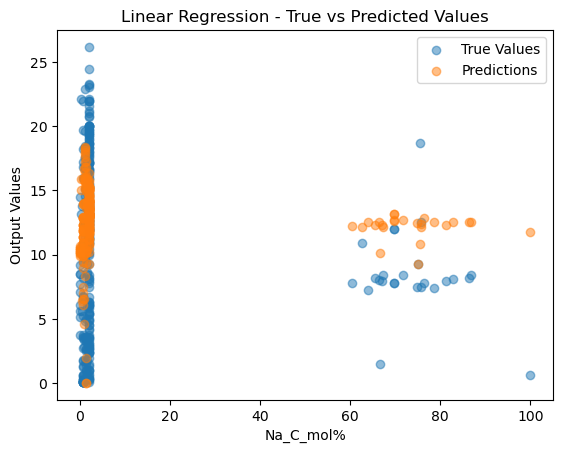

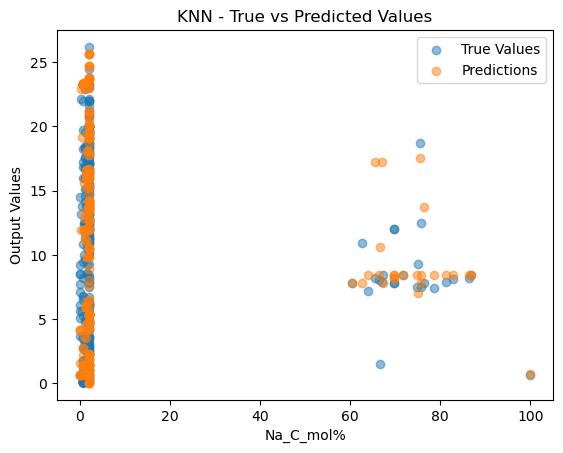

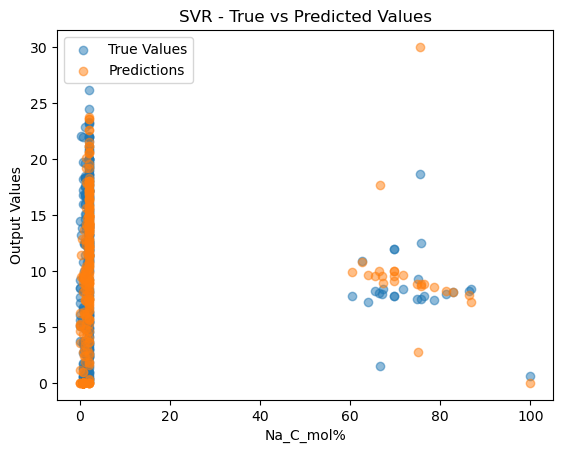

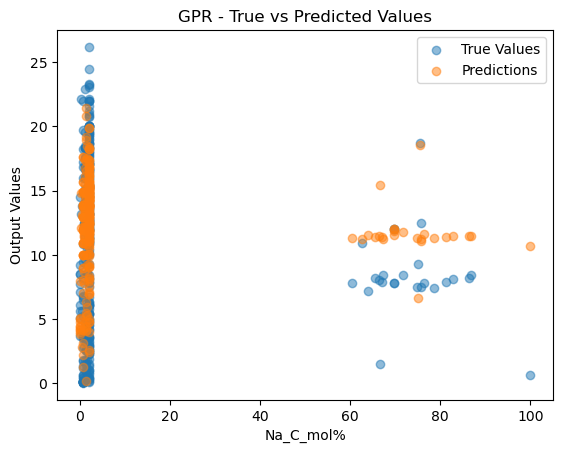

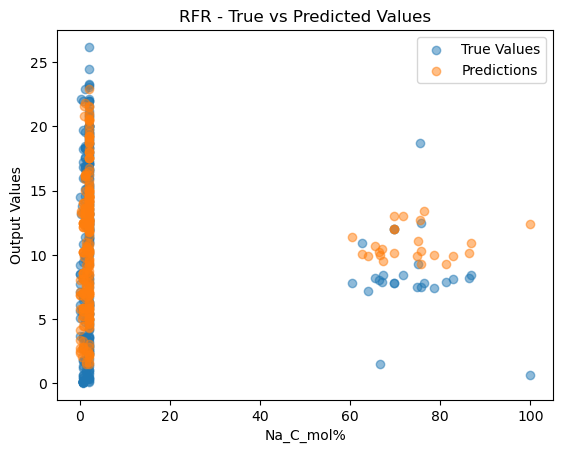

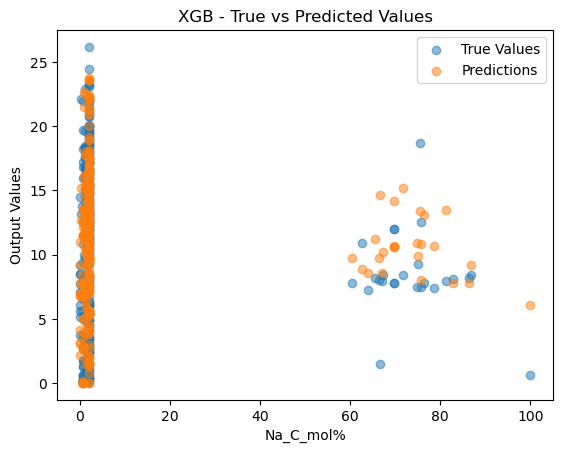

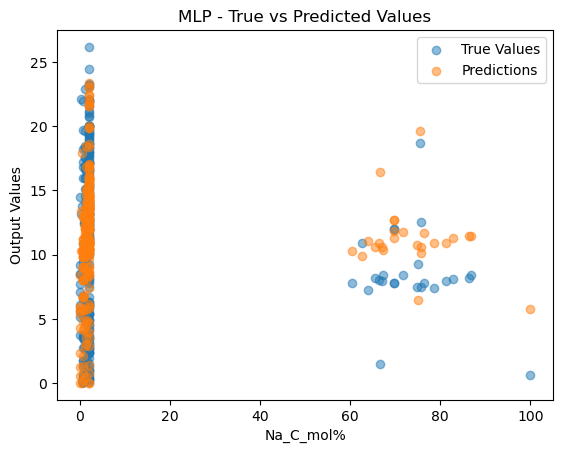

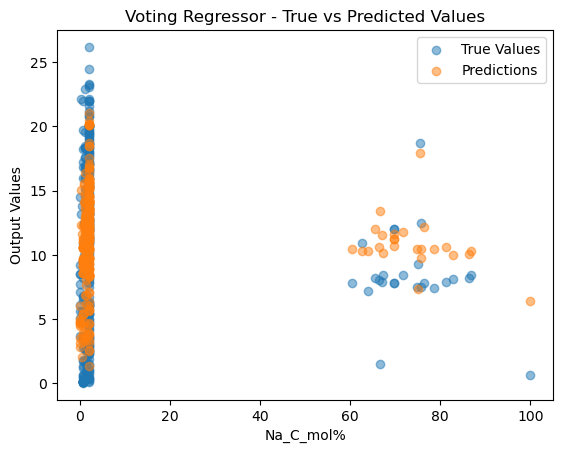

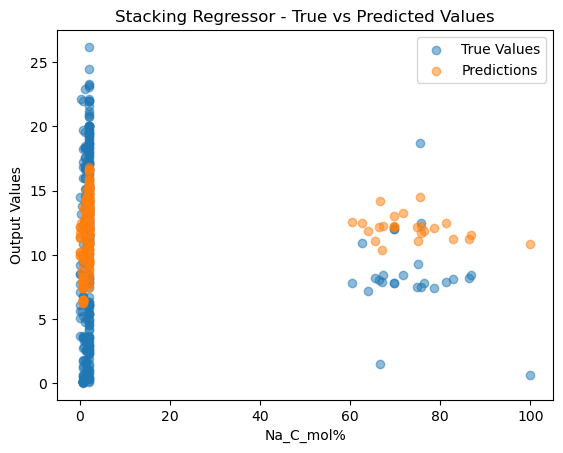

In [ ]:
def plot_scatter_with_x_axis(x_values, y_true, y_pred, model_name):
    plt.scatter(x_values, y_true, label='True Values', alpha=0.5)
    plt.scatter(x_values, y_pred, label='Predictions', alpha=0.5)
    plt.xlabel('Na_C_mol%')
    plt.ylabel('Output Values')
    plt.title(f'{model_name} - True vs Predicted Values')
    plt.legend()
    plt.show()

na_c_mol_percent_values = test_data['Na_C_mol%'].values

plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, lr_predictions_original, 'Linear Regression')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, knn_predictions_original, 'KNN')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, svr_predictions_original, 'SVR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, gpr_predictions_original, 'GPR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, rfr_predictions_original, 'RFR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, xgb_predictions_original, 'XGB')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, mlp_predictions_original, 'MLP')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, voting_predictions_original, 'Voting Regressor')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, stacking_predictions_original, 'Stacking Regressor')

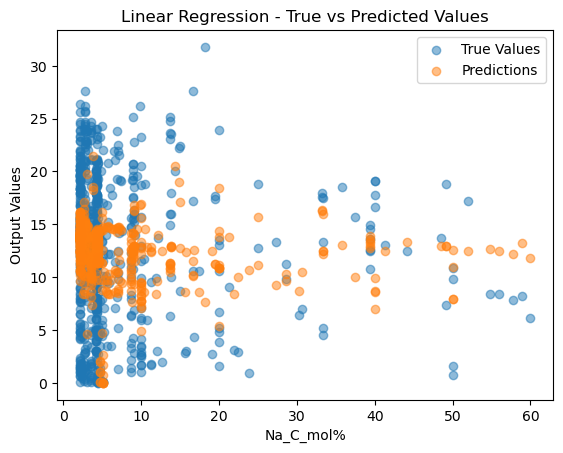

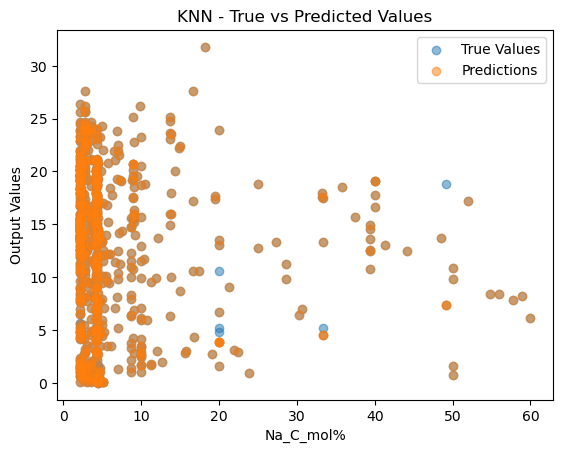

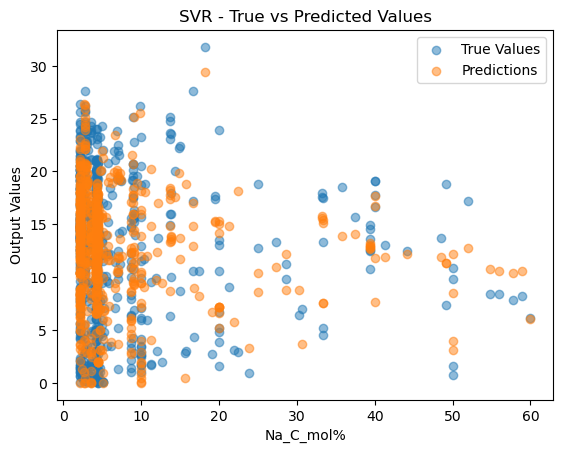

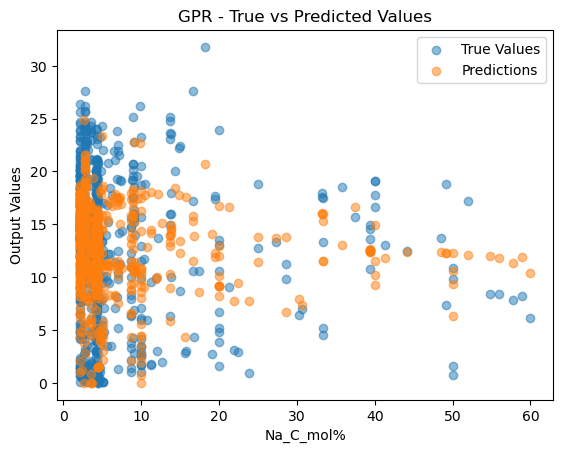

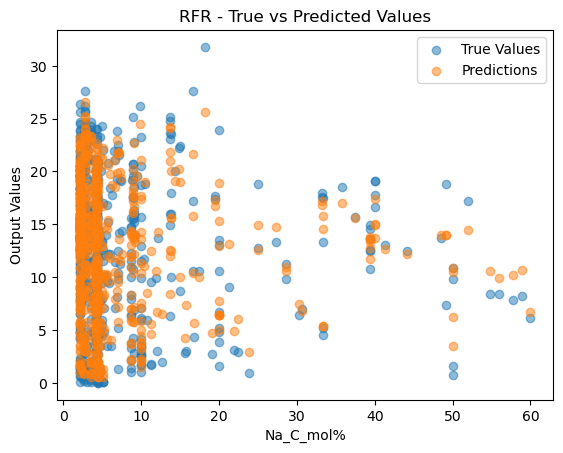

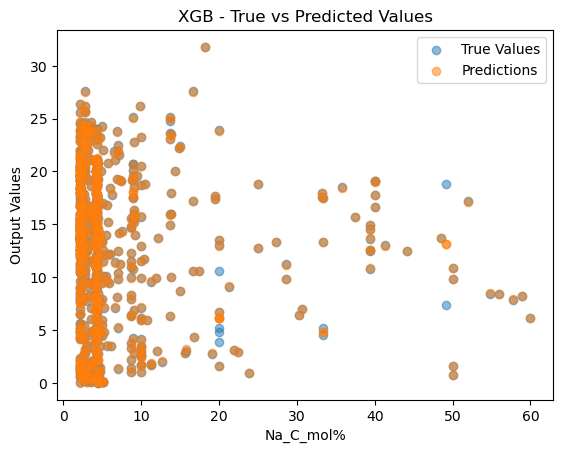

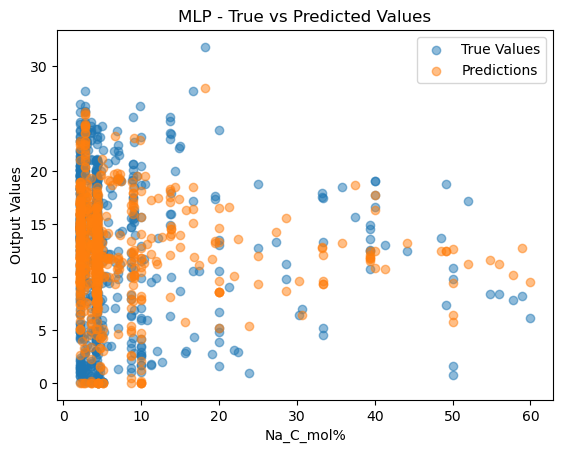

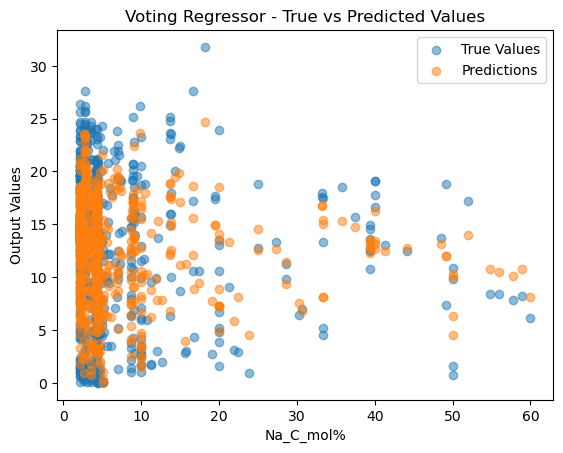

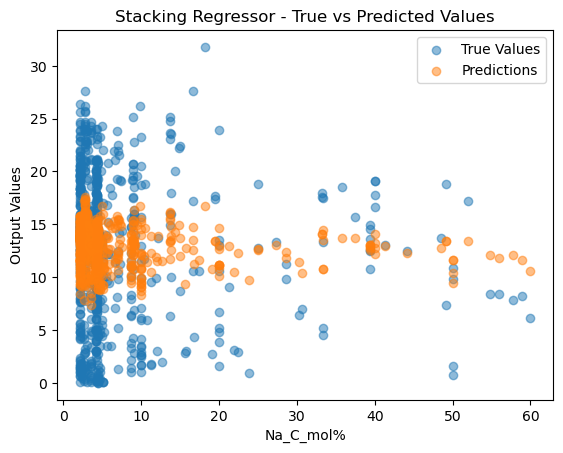

In [ ]:
def plot_scatter_with_x_axis(x_values, y_true, y_pred, model_name):
    plt.scatter(x_values, y_true, label='True Values', alpha=0.5)
    plt.scatter(x_values, y_pred, label='Predictions', alpha=0.5)
    plt.xlabel('Na_C_mol%')
    plt.ylabel('Output Values')
    plt.title(f'{model_name} - True vs Predicted Values')
    plt.legend()
    plt.show()

na_c_mol_percent_values = train_data['Na_C_mol%'].values

plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, lr_predictions_original_train, 'Linear Regression')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, knn_predictions_original_train, 'KNN')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, svr_predictions_original_train, 'SVR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, gpr_predictions_original_train, 'GPR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, rfr_predictions_original_train, 'RFR')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, xgb_predictions_original_train, 'XGB')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, mlp_predictions_original_train, 'MLP')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, voting_predictions_original_train, 'Voting Regressor')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_train, stacking_predictions_original_train, 'Stacking Regressor')

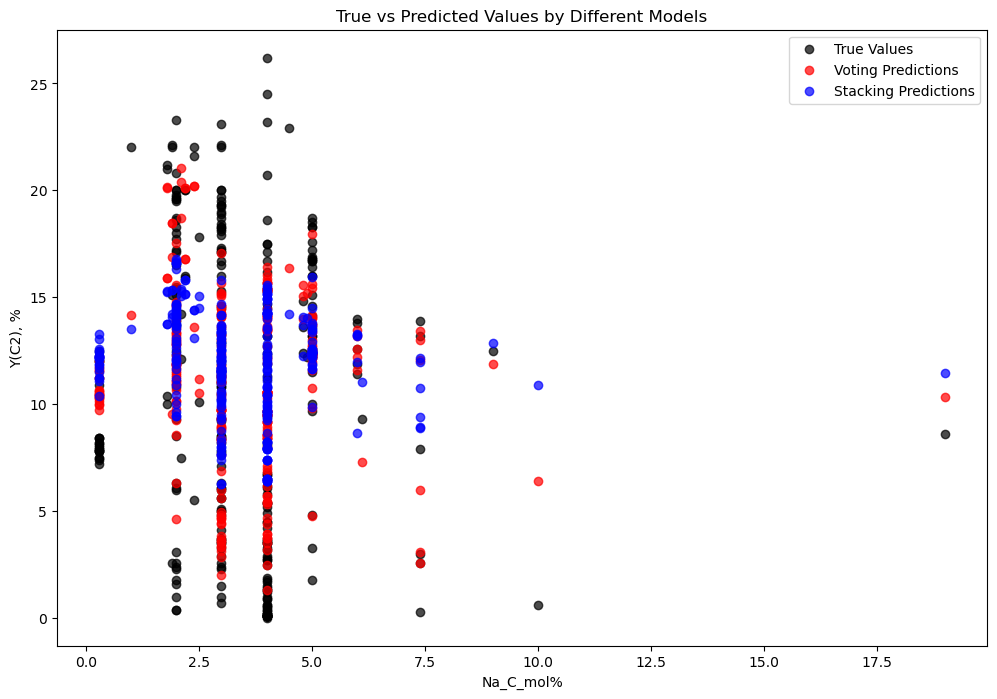

In [ ]:
# Create a scatter plot
plt.figure(figsize=(12, 8))

# Plot the true values
plt.scatter(na_c_mol_percent_values, y_test, label='True Values', color='black', alpha=0.7)

# Plot the predictions from different models
# plt.scatter(na_c_mol_percent_values, lr_predictions_original, label='LR Predictions', color='blue', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, knn_predictions_original, label='KNN Predictions', color='green', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, svr_predictions_original, label='SVR Predictions', color='red', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, gpr_predictions_original, label='GPR Predictions', color='orange', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, rfr_predictions_original, label='RFR Predictions', color='purple', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, xgb_predictions_original, label='XGB Predictions', color='brown', alpha=0.7)
# plt.scatter(na_c_mol_percent_values, mlp_predictions_original, label='MLP Predictions', color='pink', alpha=0.7)
plt.scatter(na_c_mol_percent_values, voting_predictions_original, label='Voting Predictions', color='red', alpha=0.7)
plt.scatter(na_c_mol_percent_values, stacking_predictions_original, label='Stacking Predictions', color='blue', alpha=0.7)

# Add labels, title, and legend
plt.xlabel('Na_C_mol%')
plt.ylabel('Y(C2), %')
plt.title('True vs Predicted Values by Different Models')
plt.legend()

plt.show()

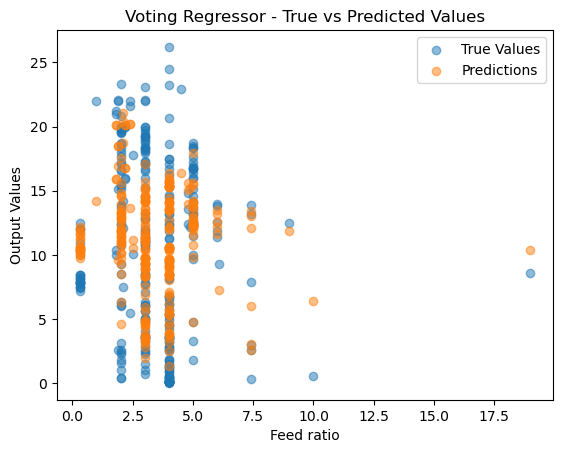

In [ ]:
def plot_scatter_with_x_axis(x_values, y_true, y_pred, model_name):
    plt.scatter(x_values, y_true, label='True Values', alpha=0.5)
    plt.scatter(x_values, y_pred, label='Predictions', alpha=0.5)
    plt.xlabel('Feed ratio')
    plt.ylabel('Output Values')
    plt.title(f'{model_name} - True vs Predicted Values')
    plt.legend()
    plt.show()

na_c_mol_percent_values = test_data['p(CH4)/p(O2)'].values

# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, lr_predictions_original, 'Linear Regression')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, knn_predictions_original, 'KNN')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, svr_predictions_original, 'SVR')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, gpr_predictions_original, 'GPR')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, rfr_predictions_original, 'RFR')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, xgb_predictions_original, 'XGB')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, mlp_predictions_original, 'MLP')
plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, voting_predictions_original, 'Voting Regressor')
# plot_scatter_with_x_axis(na_c_mol_percent_values, y_test, stacking_predictions_original, 'Stacking Regressor')



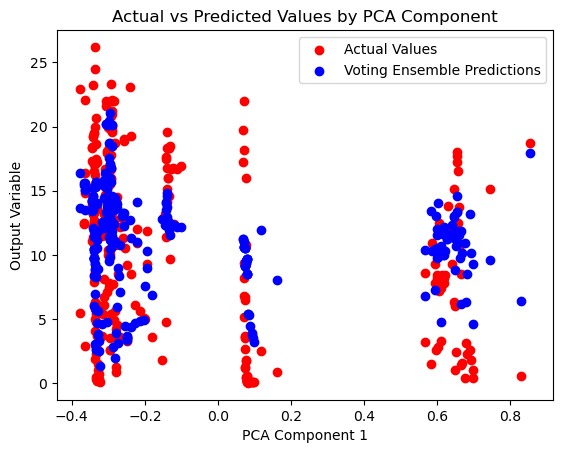

In [ ]:
# 예측값을 1차원 배열로 변환
voting_predictions_flatten = voting_predictions_original.flatten()

# 첫 번째 주성분만 추출
X_test_pca_first_component = X_test_pca[:, 0]

# 형태가 동일한지 확인
if X_test_pca_first_component.shape == y_test.shape == voting_predictions_flatten.shape:
    plt.scatter(X_test_pca_first_component, y_test, label='Actual Values', color='red')
    plt.scatter(X_test_pca_first_component, voting_predictions_flatten, label='Voting Ensemble Predictions', color='blue')
    plt.xlabel('PCA Component 1')
    plt.ylabel('Output Variable')
    plt.title('Actual vs Predicted Values by PCA Component')
    plt.legend()
    plt.show()
else:
    print("Shapes are not matching!")

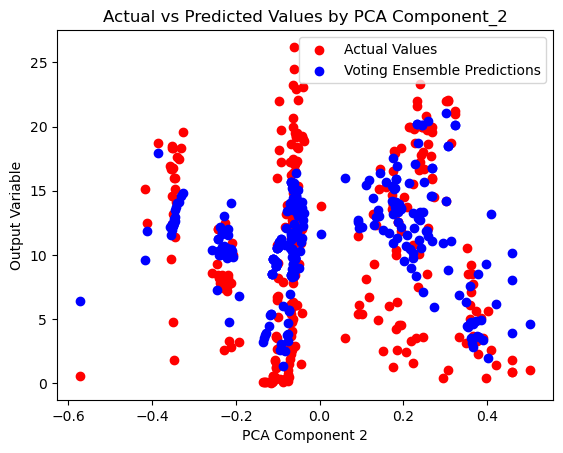

In [ ]:
# 첫 번째 주성분만 추출
X_test_pca_first_component = X_test_pca[:, 1]

# 형태가 동일한지 확인
if X_test_pca_first_component.shape == y_test.shape == voting_predictions_flatten.shape:
    plt.scatter(X_test_pca_first_component, y_test, label='Actual Values', color='red')
    plt.scatter(X_test_pca_first_component, voting_predictions_flatten, label='Voting Ensemble Predictions', color='blue')
    plt.xlabel('PCA Component 2')
    plt.ylabel('Output Variable')
    plt.title('Actual vs Predicted Values by PCA Component_2')
    plt.legend()
    plt.show()
else:
    print("Shapes are not matching!")

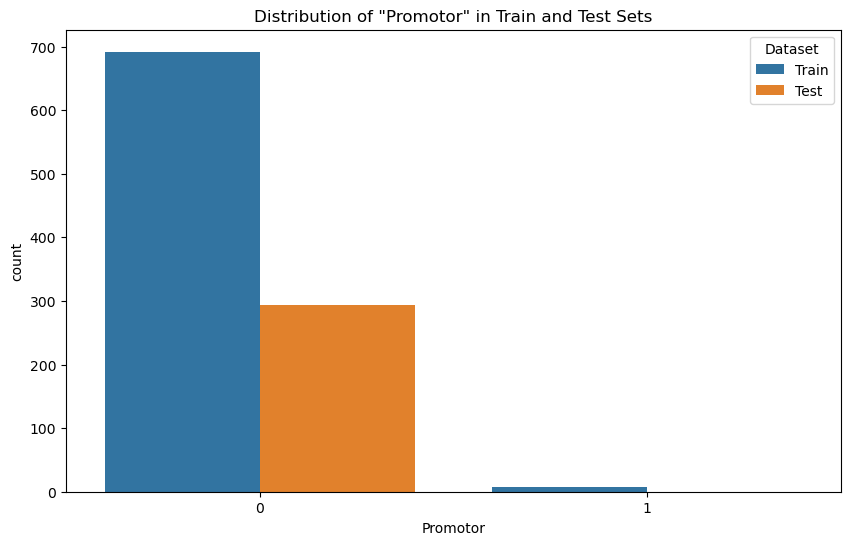

In [ ]:
# Create DataFrame for easy plotting
df_train = pd.DataFrame({'Promotor': X_train['Promotor'], 'Dataset': 'Train'})
df_test = pd.DataFrame({'Promotor': X_test['Promotor'], 'Dataset': 'Test'})
df = pd.concat([df_train, df_test])

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Promotor', hue='Dataset')
plt.title('Distribution of "Promotor" in Train and Test Sets')
plt.show()

In [ ]:
from patsy import dmatrix

print(X_train[col].describe())
print(X_test[col].describe())

print(len(np.unique(X_train[col])))
print(len(np.unique(X_test[col])))

# Initialize an empty array for ensemble predictions
ensemble_predictions = np.zeros(len(y_test))

# Number of ensemble models
n_models = 1000

# Loop through each feature and fit a MARS model
for col in input_columns:
    # Create design matrices for the train and test sets for the current feature
    design_matrix_train = dmatrix("cr(x, df=3)", {"x": X_train[col]})
    design_matrix_test = dmatrix("cr(x, df=3)", {"x": X_test[col]})
    
    # Initialize temporary predictions for the ensemble
    temp_predictions = np.zeros(len(y_test))
    
    # Fit n_models number of MARS models and accumulate their predictions
    for _ in range(n_models):
        model = LinearRegression()
        model.fit(design_matrix_train, y_train)
        predictions = model.predict(design_matrix_test)
        temp_predictions += predictions

    # Average the predictions for the current feature
    temp_predictions /= n_models
    
    # Add the averaged predictions to the ensemble predictions
    ensemble_predictions += temp_predictions

# Average the ensemble predictions across all features
ensemble_predictions /= len(input_columns)

# Calculate the ensemble MSE
ensemble_mse = mean_squared_error(y_test, ensemble_predictions)

print(f"Ensemble MARS MSE: {ensemble_mse}")

KeyError: 'Sn_S_mol%'

In [ ]:
import pymc as pm
import aesara.tensor as at
import aesara

with pm.Model() as model_0:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", 10)

    mu = alpha + beta * X_train_pca

    